In [1]:
from primordialpy.background import Background
from primordialpy.model import PotentialFunction
from primordialpy.perturbations import  Perturbations
from primordialpy.pbhabundance import PBHAbundance
from primordialpy.pbhconstraints import PBHConstraints
from primordialpy.inducedGW import InducedGW

import matplotlib.pyplot as plt

## Potential

In [2]:
V = 'V0*(tanh(phi/sqrt(6)))**2*(1 + A*(sech((phi - phi0)/sigma))**2)'
parameters = {'V0' : 1.495e-10, 'A' : 1.080552e-3, 'phi0' : 5.301327, 'sigma': 1.940550e-2}
potential = PotentialFunction.function(V, param_values=parameters) 


## Background dynamics

In [3]:
background = Background(potential, phi0 = 6.3) 
background.solver()

In [4]:
N, phi, dphidN, H, a, aH, eps_H, eta_H = background.data().values()
background.save_background(path='./Data')
Nend = N[-1]
Nend

Saved to ./Data/background.dat


np.float64(77.50775077507751)

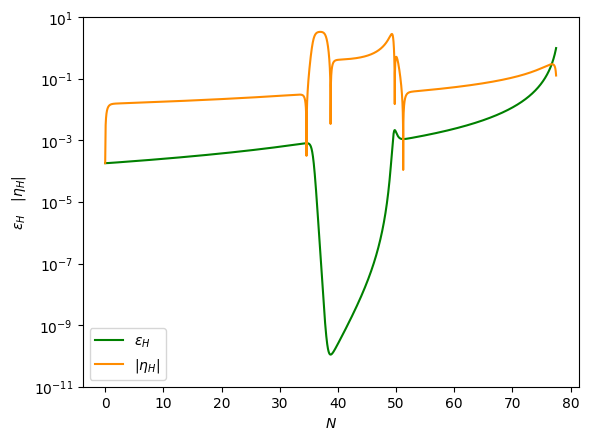

In [5]:
plt.plot(N, eps_H, label = r'$\epsilon_H$', color = 'green' )
plt.plot(N, abs(eta_H), label = r'$|\eta_H |$', color = 'darkorange')

plt.yscale('log')
plt.ylim(1e-11, 10)
plt.xlabel(r'$N$')
plt.ylabel(r'$\epsilon_H\quad |\eta_H|$')
plt.legend(loc = 3)
#plt.title('Slow-roll parameters')

## Perturbations and power spectra

In [6]:
pert = Perturbations(potential, background, scale= 'PBH', N_CMB = 63)
sol_pivot = pert.power_spectra_pivot()

Curvature power spectrum at pivot scale is 2.116659640020506e-09
Tensor to scalar ratio at pivot scale is 0.004629436332318029


In [7]:
PS = pert.power_spectrum()
pert.save_power_spectra(path ='./Data')

Computing P(k): 100%|██████████| 1000/1000 [00:28<00:00, 35.14it/s]


$Ps_peak = 3.5225\times 10^{-02}$
$k_peak = 3.7409\times 10^{+08}\,\mathrm{Mpc}^-1$
Saved to ./Data/power_spectra.dat


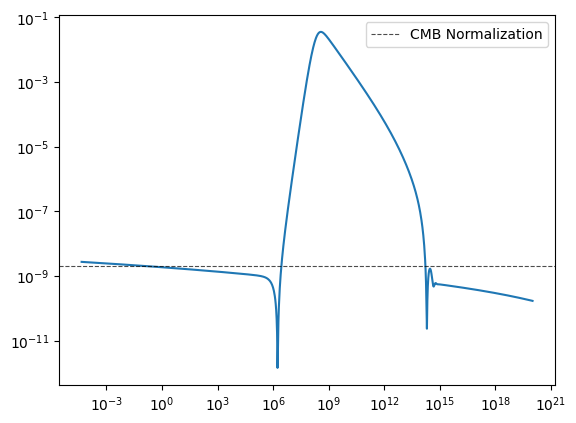

In [8]:
plt.loglog(pert.k_modes, PS[0])
plt.axhline(y = 2.1e-9, label = 'CMB Normalization', alpha = 0.7, color = 'k', linestyle = 'dashed', linewidth = 0.8)
plt.legend()

In [9]:
pert.spectral_tilts

{'n_s': 0.9603634823333502, 'n_t': -0.0006020533906531385}

## PBH abundance

In [10]:
pbh = PBHAbundance(perturbations=pert, delta_c=0.4, gamma=0.2, gstar=107.5)
mPBH, fPBH = pbh.fPBH()
pbh.save_pbh(path='./Data')

fPBH_peak = 1.5285e-02
MPBH_peak = 2.2423e-05 M_sun
Saved to ./Data/pbh_abundance.dat


<Axes: title={'center': 'Observational Constraints'}, xlabel='$M_{\\rm PBH}\\ [M_\\odot]$', ylabel='$f_{\\rm PBH}(M)$'>

<Figure size 2400x1500 with 0 Axes>

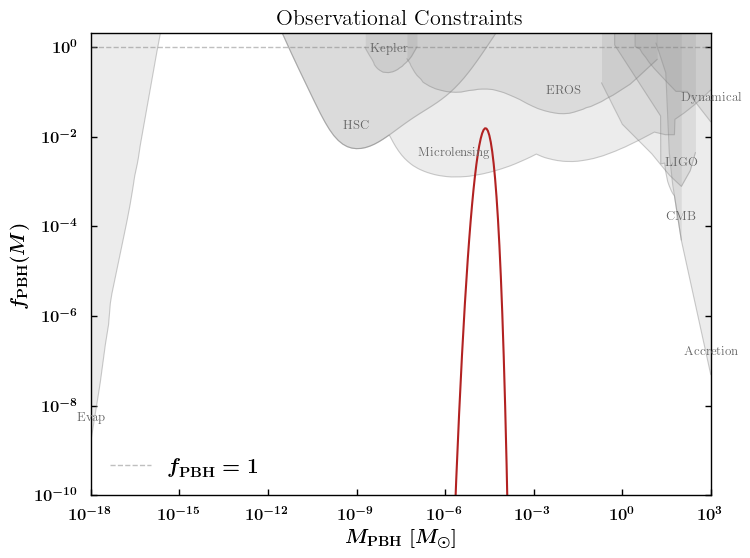

In [11]:
constraints = PBHConstraints()
constraints.add_bound('Evap', 'Evaporation.txt')
constraints.add_bound('HSC',  'HSC.txt')
constraints.add_bound('CMB', 'CMB.txt')
constraints.add_bound('LIGO', 'LIGO.txt')
constraints.add_bound('Accretion', 'Accretion.txt')
constraints.add_bound('Dynamical', 'Dynamical.txt')
constraints.add_bound('EROS', 'EROS.txt')
constraints.add_bound('Kepler', 'Kepler.txt')
constraints.add_bound('Microlensing', 'Microlensing.txt')

constraints.plot_constraints(m_pbh=mPBH, f_pbh=fPBH)

## SIGWs

In [12]:
gw = InducedGW(perturbations=pert)
f, omega = gw.compute(n_int= 1000)
gw.save_gw(path= './Data')

Computing SIGW for 1000 modes...


Integrating SIGWs: 100%|██████████| 1000/1000 [00:11<00:00, 86.91it/s]


Omega_GW_peak = 1.2187e-08
f_peak = 6.8435e-07 Hz
Saved to ./Data/gw_data.dat


(1e-13, np.float64(474258.8092713832))

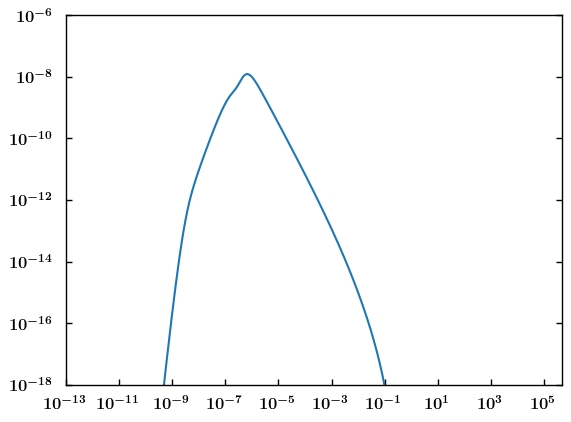

In [13]:
plt.loglog(f, omega)
plt.ylim(1e-18, 1e-6)
plt.xlim(1e-13)
